### How well do LLMs represent each country?
- Train a binary classifier for each country
- Apply the classifier to predict the probability of LLM representation
    - compare LLM probabilities with country_average probabilities
    - the best/worst/default represented countries

In [1]:
import pickle
import pandas as pd 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from scipy import stats
from matplotlib.lines import Line2D
from matplotlib import pyplot as plt

### Train binary classifier for each country
- Training samples:
    - pos: individual responses from that country
    - neg: individual responses from other countries
- Evaluate classifier performance to ensure its trustworthiness

In [ ]:
# get the representative survey items
df_avg = pd.read_csv("./data/wvs7_country_avg.csv").set_index('Country')
items = list(df_avg.columns) # load all data using the order of these items
all_countries = list(df_avg.index)
df_avg.shape

(66, 117)

In [3]:
df_avg.head()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Country,,,,,,,,,,,,,,,,,,,,,
Andorra,0.961487,0.821381,0.859562,0.353293,0.824684,0.344977,0.763280,0.772410,0.414796,0.255744,...,0.904287,0.516966,0.549432,0.044245,0.032934,0.033966,0.145563,0.662338,0.366000,0.036703
Argentina,0.969425,0.819541,0.730063,0.397602,0.843865,0.535354,0.729400,0.711538,0.374747,0.206933,...,0.524476,0.492355,0.474400,0.096141,0.372294,0.133667,0.191049,0.641642,0.364729,0.066667
Armenia,0.982284,0.746318,0.698951,0.429276,0.885246,0.866831,0.771091,0.565057,0.633005,0.081081,...,0.532125,0.646848,0.731397,0.130553,0.047893,0.173508,0.284739,0.447547,0.178037,0.038189
Australia,0.963209,0.840128,0.784548,0.529389,0.668203,0.367424,0.739058,0.736219,0.474972,0.540179,...,0.663887,0.415698,0.393101,0.055370,0.177506,0.101764,0.145717,0.767468,0.564278,0.017065
Bangladesh,0.995000,0.643813,0.602747,0.307890,0.925802,0.977444,0.721667,0.678750,0.329163,0.129274,...,0.716152,0.544275,0.756312,0.173901,0.127197,0.352810,0.413861,0.740151,0.274707,0.099659


In [ ]:
# read individual response
df_wvs = pd.read_csv("./data/wvs7_scaled.csv")[['Country'] + items].set_index('Country')
print(df_wvs.shape)
display(df_wvs.head())


(97220, 117)


,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Country,,,,,,,,,,,,,,,,,,,,,
Andorra,1.0,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,0.50,0.500000,0.0,...,1.000000,0.666667,0.666667,0.0,0.0,0.0,0.000000,1.0,0.0,0.0
Andorra,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.00,0.500000,0.0,...,1.000000,0.666667,0.666667,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
Andorra,1.0,0.666667,0.666667,0.666667,0.333333,0.333333,0.666667,1.00,0.500000,0.0,...,1.000000,0.333333,0.000000,0.0,0.0,0.0,0.333333,1.0,1.0,0.0
Andorra,1.0,1.000000,1.000000,0.000000,0.666667,0.000000,0.666667,0.75,0.414796,0.0,...,0.666667,0.666667,0.666667,0.0,0.0,0.0,0.000000,1.0,1.0,0.0
Andorra,1.0,1.000000,1.000000,0.333333,1.000000,0.333333,0.666667,0.75,0.500000,0.0,...,0.666667,0.666667,0.666667,0.0,0.0,0.0,0.000000,1.0,0.0,0.0


In [6]:
def construct_train_samples(ctry, use_items):
    """Construct training samples"""
    df_pos = df_wvs.loc[ctry][use_items].assign(label=1)
    df_neg = df_wvs[df_wvs.index != ctry][use_items].sample(n=df_pos.shape[0], random_state=42).assign(label=0)
    df_train = pd.concat([df_pos, df_neg], ignore_index=True)
    return df_train

def train_and_evaluate(X, y):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    result = {}
    for eval in ['accuracy','precision','recall','f1']:
        scores = cross_val_score(clf, X, y, cv=5, scoring=eval)
        result[eval] = round(scores.mean(),3)
    clf.fit(X, y)
    return clf, result

def train_country_classifiers(use_items):
    """for each country, train a binary classifier"""
    ctry_classifiers = {}
    clf_evaluations = []
    for ctry in all_countries:
        # print(ctry)
        df_train = construct_train_samples(ctry, use_items)
        X = df_train[use_items].values
        y = df_train['label'].values
        clf, clf_eval = train_and_evaluate(X, y)
        clf_eval['Country'] = ctry
        clf_eval['samples'] = int(df_train.shape[0]/2)
        clf_evaluations.append(clf_eval)
        ctry_classifiers[ctry] = clf
    
    return pd.DataFrame(clf_evaluations).set_index('Country'), ctry_classifiers

In [7]:
# takes 30 seconds to run
df_clf, ctry_classifiers = train_country_classifiers(items)
df_clf

,accuracy,precision,recall,f1,samples
Country,,,,,
Andorra,0.942,0.943,0.941,0.942,1004
Argentina,0.882,0.892,0.869,0.879,1003
Armenia,0.942,0.944,0.939,0.942,1223
Australia,0.873,0.862,0.888,0.875,1813
Bangladesh,0.953,0.958,0.949,0.953,1200
...,...,...,...,...,...
Uruguay,0.882,0.884,0.878,0.881,1000
Uzbekistan,0.922,0.927,0.916,0.921,1250
Venezuela,0.890,0.903,0.873,0.888,1190


In [8]:
# the average F1 score of all countries, overall good performance
for eval in ['accuracy','precision','recall','f1']:
    print(f"{eval}: {df_clf[eval].mean().round(3)}")

accuracy: 0.912
precision: 0.914
recall: 0.91
f1: 0.912


In [ ]:
# with open("./data/ctry_classifiers.pkl", "wb") as f:
#     pickle.dump(ctry_classifiers, f)

with open("./data/ctry_classifiers.pkl", "rb") as f:
    ctry_classifiers = pickle.load(f)

### Apply the classifier to predict the probability of LLM representation
- probability: how likely this representation is from the target country
- compare LLM probabilities with country_average probabilities
- the best/worst/default represented countries

In [ ]:
# LLM country representation
df_gpt = pd.read_csv("./data/gpt_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries+['model']]
df_deepseek = pd.read_csv("./data/deepseek_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries+['model']]
df_claude = pd.read_csv("./data/claude_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries+['model']]

df_gpt.shape, df_claude.shape, df_deepseek.shape

((67, 117), (67, 117), (67, 117))

In [11]:
def predict_probability(ctry_classifiers, df_llm):
    """predict the probability of LLM country representation and average human representation"""
    llm_ctry_prob = {}
    avg_ctry_prob = {}
    llm_default_prob = {}
    llm_default = df_llm.loc['model'].values

    for ctry in all_countries:
        clf = ctry_classifiers[ctry]

        llm_ctry = df_llm.loc[ctry][items].values
        llm_ctry_prob[ctry] = clf.predict_proba([llm_ctry])[0][1].round(3)
        llm_default_prob[ctry] = clf.predict_proba([llm_default])[0][1].round(3)
        
        ctry_avg = df_avg.loc[ctry][items].values
        avg_ctry_prob[ctry] = clf.predict_proba([ctry_avg])[0][1].round(3)
        
    return avg_ctry_prob, llm_default_prob, llm_ctry_prob

In [12]:
avg_ctry_prob, gpt_default_prob, gpt_ctry_prob = predict_probability(ctry_classifiers,df_gpt)
df_clf['avg_ctry_prob'] = df_clf.index.map(avg_ctry_prob)
df_clf['gpt_default_prob'] = df_clf.index.map(gpt_default_prob)
df_clf['gpt_ctry_prob'] = df_clf.index.map(gpt_ctry_prob)

avg_ctry_prob, claude_default_prob, claude_ctry_prob = predict_probability(ctry_classifiers,df_claude)
df_clf['claude_default_prob'] = df_clf.index.map(claude_default_prob)
df_clf['claude_ctry_prob'] = df_clf.index.map(claude_ctry_prob)

avg_ctry_prob, deepseek_default_prob, deepseek_ctry_prob = predict_probability(ctry_classifiers,df_deepseek)
df_clf['deepseek_default_prob'] = df_clf.index.map(deepseek_default_prob)
df_clf['deepseek_ctry_prob'] = df_clf.index.map(deepseek_ctry_prob)

df_clf.head()

,accuracy,precision,recall,f1,samples,avg_ctry_prob,gpt_default_prob,gpt_ctry_prob,claude_default_prob,claude_ctry_prob,deepseek_default_prob,deepseek_ctry_prob
Country,,,,,,,,,,,,
Andorra,0.942,0.943,0.941,0.942,1004,0.987,0.024,0.648,0.102,0.182,0.145,0.252
Argentina,0.882,0.892,0.869,0.879,1003,0.965,0.000,0.026,0.220,0.299,0.004,0.011
Armenia,0.942,0.944,0.939,0.942,1223,0.993,0.014,0.032,0.003,0.048,0.012,0.247
Australia,0.873,0.862,0.888,0.875,1813,0.916,0.530,0.806,0.437,0.897,0.470,0.852
Bangladesh,0.953,0.958,0.949,0.953,1200,0.994,0.003,0.016,0.000,0.369,0.003,0.589


In [ ]:
# with open("./data/clf_predictions.pkl", "wb") as f:
#     pickle.dump(df_clf, f)

with open("./data/clf_predictions.pkl", "rb") as f:
    df_clf = pickle.load(f)

In [14]:
display(df_clf[['gpt_ctry_prob', 'claude_ctry_prob', 'deepseek_ctry_prob' ]].corr().round(3)) 

,gpt_ctry_prob,claude_ctry_prob,deepseek_ctry_prob
gpt_ctry_prob,1.000,0.699,0.699
claude_ctry_prob,0.699,1.000,0.831
deepseek_ctry_prob,0.699,0.831,1.000


In [18]:
# predicted probability for llm representation and country_average representation
df_clf['gpt_ctry_prob'].mean().round(3), df_clf['claude_ctry_prob'].mean().round(3),df_clf['deepseek_ctry_prob'].mean().round(3), df_clf['avg_ctry_prob'].mean().round(3)

(np.float64(0.28), np.float64(0.264), np.float64(0.301), np.float64(0.97))

In [19]:
# 18/66 countries have "accurate" llm representations
df_clf[df_clf['gpt_ctry_prob']>0.5].shape, df_clf[df_clf['claude_ctry_prob']>0.5].shape, df_clf[df_clf['deepseek_ctry_prob']>0.5].shape

((18, 12), (14, 12), (13, 12))

In [ ]:
def visualize_llm_horizontal():
    df_clf['llm_avg_prob'] = df_clf[['gpt_ctry_prob', 'claude_ctry_prob', 'deepseek_ctry_prob']].mean(axis=1)

    cols = ['avg_ctry_prob', 'gpt_ctry_prob', 'claude_ctry_prob', 'deepseek_ctry_prob', 'llm_avg_prob']
    colors = {
        'avg_ctry_prob':     'steelblue',
        'gpt_ctry_prob':     'orange',
        'claude_ctry_prob':  'purple',
        'deepseek_ctry_prob':'green',
        'llm_avg_prob':      'brown',
    }
    markers = {
        'avg_ctry_prob':     'o',
        'gpt_ctry_prob':     '_',
        'claude_ctry_prob':  '_',
        'deepseek_ctry_prob':'_',
        'llm_avg_prob':      'o',
    }
    sizes = {
        'avg_ctry_prob':     30,
        'gpt_ctry_prob':     80,
        'claude_ctry_prob':  80,
        'deepseek_ctry_prob':80,
        'llm_avg_prob':      30,
    }
    alphas = {
        'avg_ctry_prob':     1.0,
        'gpt_ctry_prob':     1,
        'claude_ctry_prob':  1,
        'deepseek_ctry_prob':1,
        'llm_avg_prob':      1.0,
    }
    linewidths = {
        'avg_ctry_prob':     1.0,
        'gpt_ctry_prob':     1.5,
        'claude_ctry_prob':  1.5,
        'deepseek_ctry_prob':1.5,
        'llm_avg_prob':      1.0,
    }
    labels = {
        'avg_ctry_prob':     'Country-average of Human (%.3f)' % df_clf['avg_ctry_prob'].mean(),
        'gpt_ctry_prob':     'GPT (%.3f)'                      % df_clf['gpt_ctry_prob'].mean(),
        'claude_ctry_prob':  'Claude (%.3f)'                   % df_clf['claude_ctry_prob'].mean(),
        'deepseek_ctry_prob':'DeepSeek (%.3f)'                 % df_clf['deepseek_ctry_prob'].mean(),
        'llm_avg_prob':      'LLM average (%.3f)'              % df_clf['llm_avg_prob'].mean(),
    }

    df_plot = df_clf[cols].sort_values('llm_avg_prob', ascending=False)

    fig, ax = plt.subplots(figsize=(22, 8))

    for ctry, row in df_plot.iterrows():
        ax.plot([ctry, ctry], [row[cols].min(), row[cols].max()],
                color='gray', linewidth=0.8, alpha=0.4, zorder=1)

    for col in cols:
        ax.scatter(df_plot.index, df_plot[col], s=sizes[col], label=labels[col],
                   color=colors[col], marker=markers[col], alpha=alphas[col],
                   linewidths=linewidths[col], zorder=2)

    for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
        ax.axhline(thresh, color='grey', linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_ylabel('Classifier Predicted Probability', fontsize=20)
    ax.set_title('Country-Classifier Prediction for LLM and Human Representations',
                 fontsize=25, fontweight='bold', pad=50)

    # legend order: Human avg, LLM avg, GPT, Claude, DeepSeek
    handles, leg_labels = ax.get_legend_handles_labels()
    order = [0, 4, 1, 2, 3]
    ax.legend([handles[i] for i in order], [leg_labels[i] for i in order],
              loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=5,
              fontsize=17, frameon=False)

    ax.yaxis.set_tick_params(right=True, labelright=True)
    ax.tick_params(axis='y', labelsize=17)
    plt.setp(ax.get_xticklabels(), rotation=90, ha='center', fontsize=17)
    ax.margins(x=0.01)
    # plt.savefig(f'./mainfig/1_ctry_clf.pdf', dpi=300,  bbox_inches='tight')

    plt.tight_layout()
    plt.show()

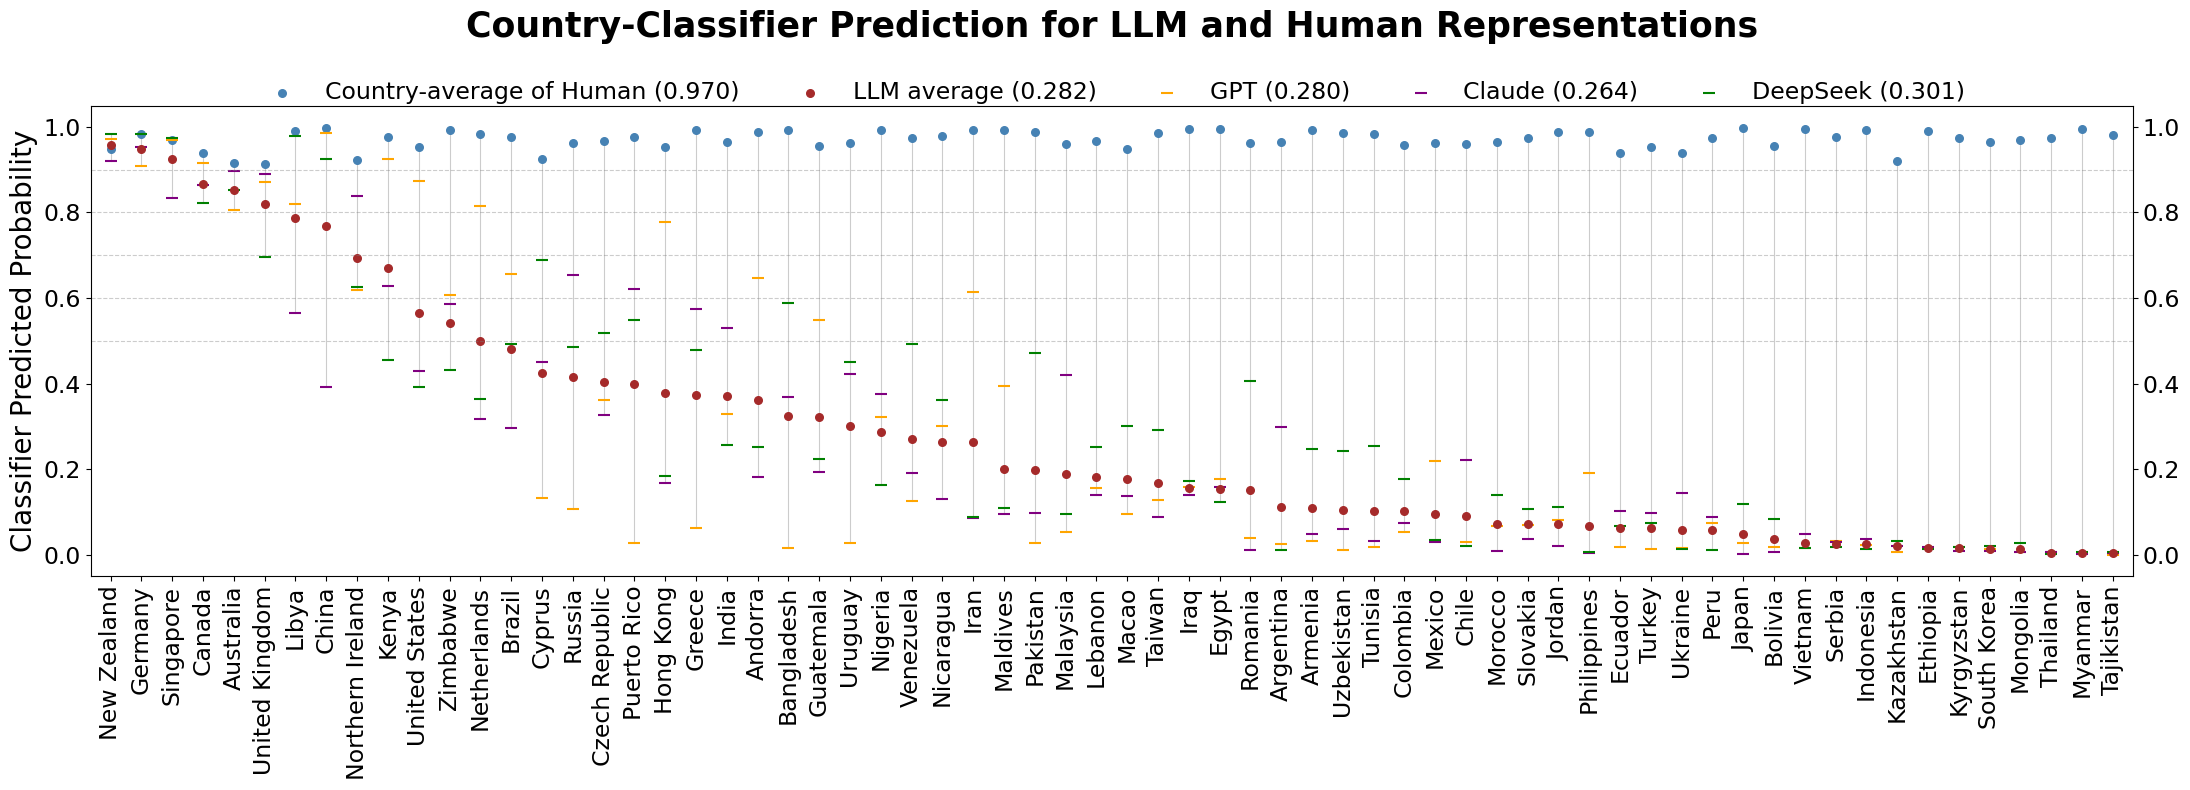

In [9]:
visualize_llm_horizontal()

In [10]:
llm_configs = [
        ('GPT',      'gpt_ctry_prob',      'orange'),
        ('Claude',   'claude_ctry_prob',   'purple'),
        ('DeepSeek', 'deepseek_ctry_prob', 'green'),
    ]

In [ ]:
def visualize_llm_singleplot(llm_config):
    fig, ax = plt.subplots(1, 1, figsize=(22, 8))

    llm_name, col, color = llm_config
    df_plot = df_clf.sort_values(col, ascending=False)

    for ctry, row in df_plot.iterrows():
        ax.plot([ctry, ctry], [row[col], row['avg_ctry_prob']],
                color='gray', linewidth=0.8, alpha=0.5, zorder=1)

    ax.scatter(df_plot.index, df_plot[col], s=20,
               label='%s (%.3f)' % (llm_name, df_clf[col].mean()),
               color=color, zorder=2)
    ax.scatter(df_plot.index, df_plot['avg_ctry_prob'], s=20,
               label='Human avg (%.3f)' % df_clf['avg_ctry_prob'].mean(),
               color='steelblue', marker='o', zorder=2)

    for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
        ax.axhline(thresh, color='red', linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_ylabel('Classifier Predicted Probability', fontsize=20)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2,
              fontsize=20, frameon=False)
    ax.yaxis.set_tick_params(right=True, labelright=True)
    ax.tick_params(axis='y', labelsize=17)
    plt.setp(ax.get_xticklabels(), rotation=90, ha='center', fontsize=18)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.margins(x=0.01)

    fig.suptitle('Country-Classifier Prediction for ' + llm_name + ' and Human Representations',
                 fontsize=25, fontweight='bold', y=0.95)
    plt.tight_layout()
    # plt.savefig('./supfig/1_ctry_clf_' + llm_name + '.pdf', dpi=300, bbox_inches='tight')
    plt.show()


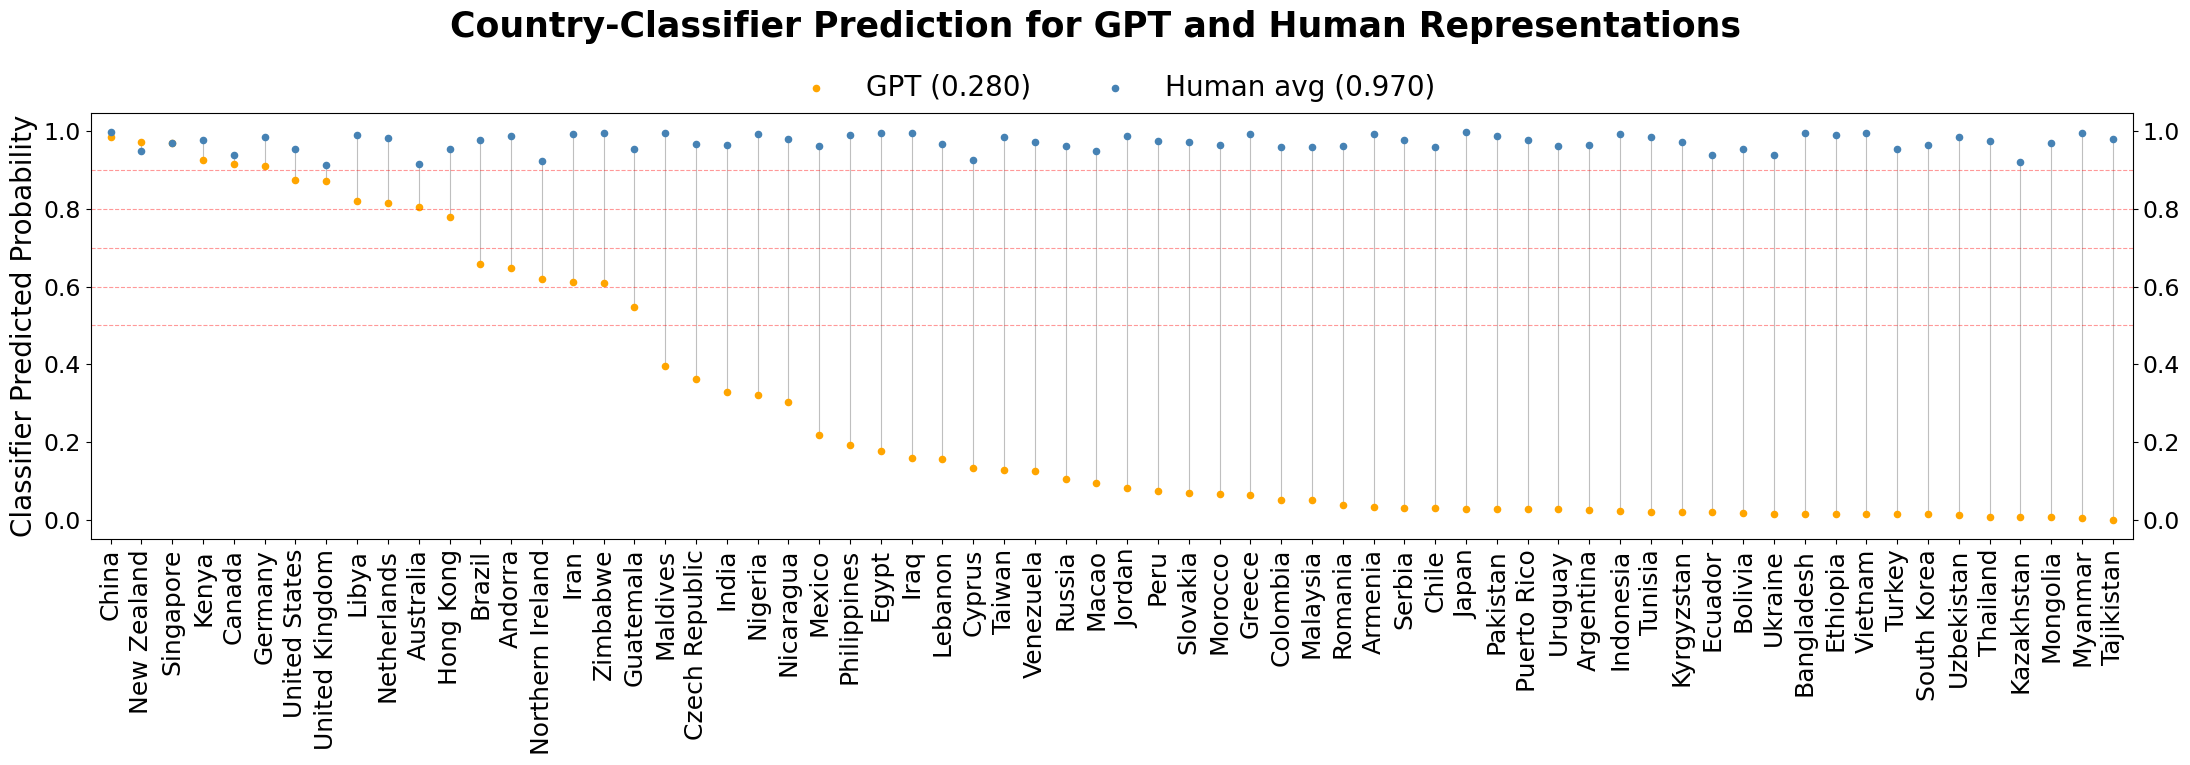

In [23]:
visualize_llm_singleplot(llm_configs[0])

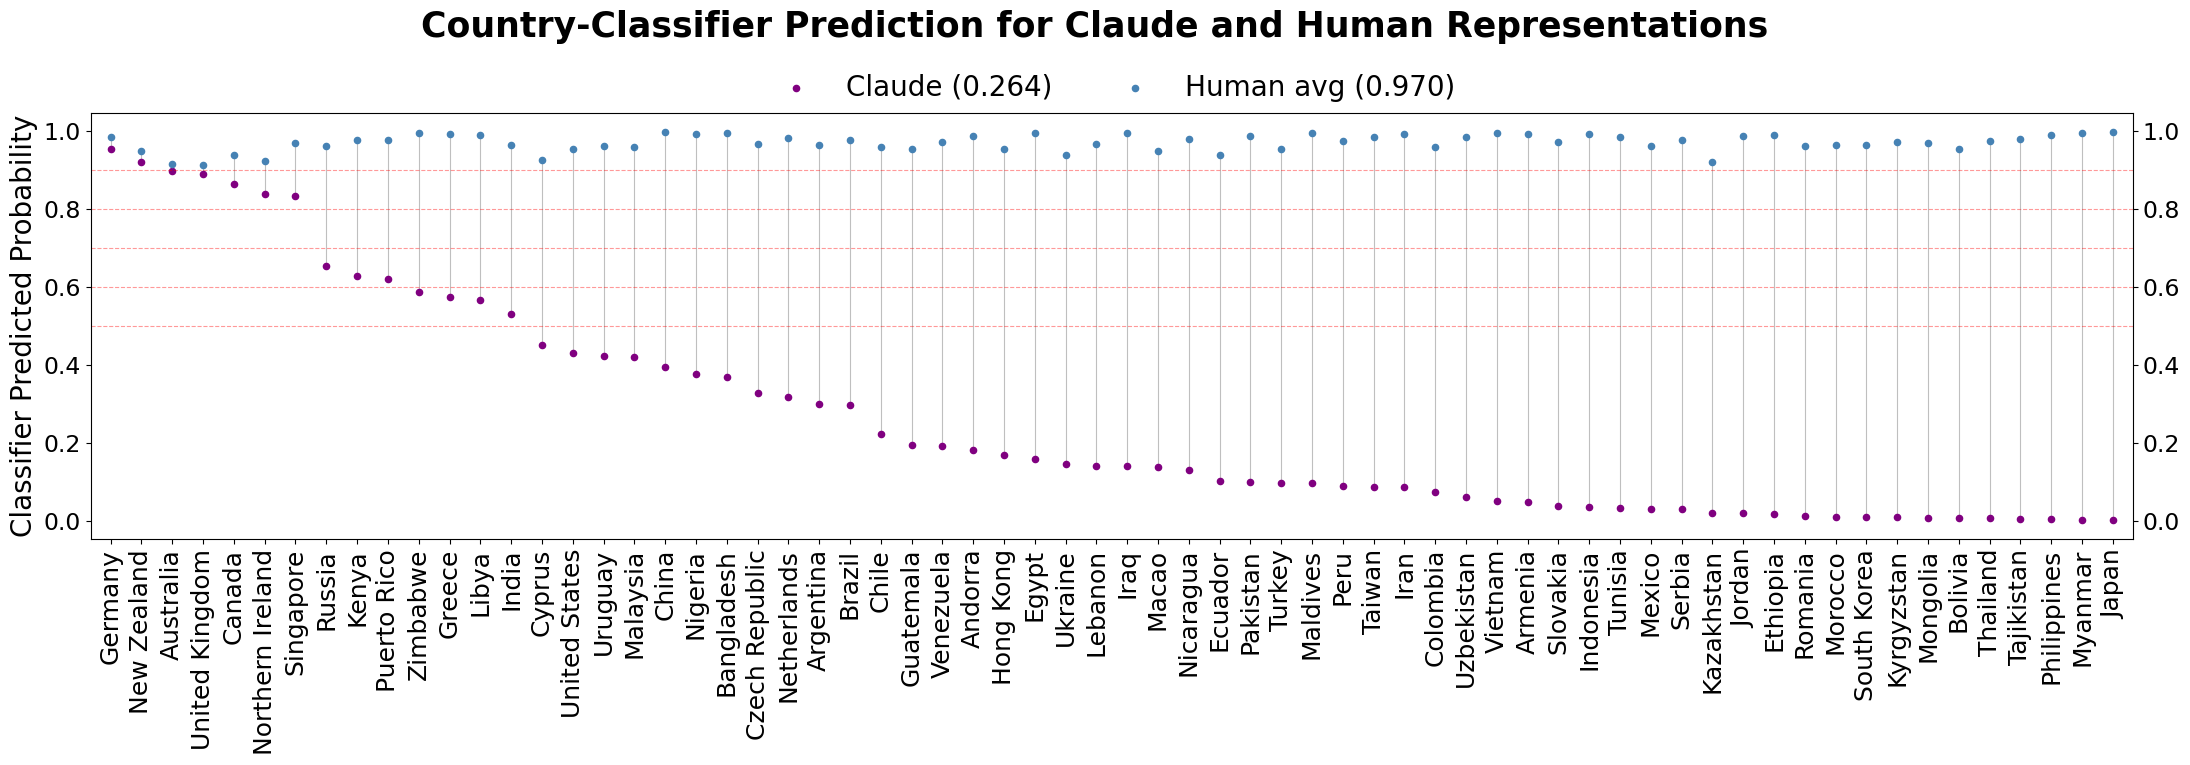

In [24]:
visualize_llm_singleplot(llm_configs[1])

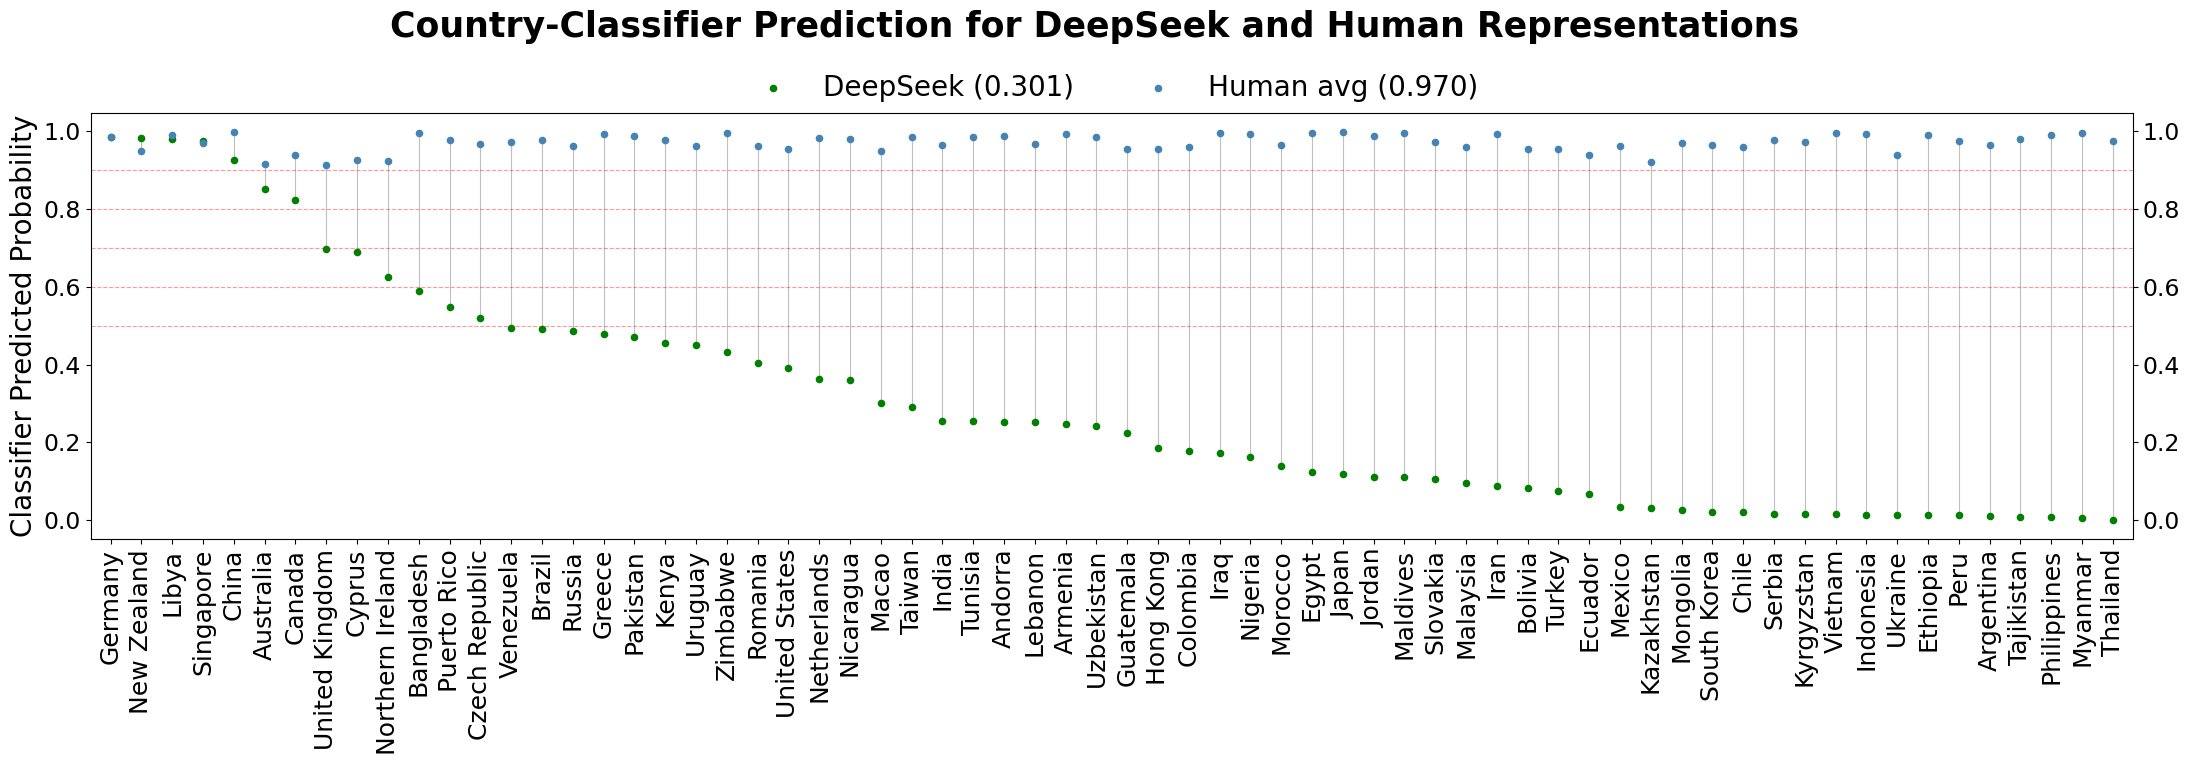

In [25]:
visualize_llm_singleplot(llm_configs[2])

- Visualize probability improvements by bar charts

In [ ]:
def visualize_prob_improve():
    df_plot = df_clf.copy()
    for llm_name, ctry_col, _ in llm_configs:
        llm_l = llm_name.lower()
        df_plot[llm_l + '_improve'] = df_plot[ctry_col] - df_plot[llm_l + '_default_prob']

    fig, axes = plt.subplots(3, 1, figsize=(22, 14))

    for ax, (llm_name, ctry_col, color) in zip(axes, llm_configs):
        improve_col = llm_name.lower() + '_improve'
        df_sorted = df_plot.sort_values(improve_col, ascending=False)
        ax.bar(df_sorted.index, df_sorted[improve_col], color=color, alpha=0.8,
               label='%s (avg %.3f)' % (llm_name, df_sorted[improve_col].mean()))
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel('Improved Probability', fontsize=17)
        ax.legend(loc='upper right', fontsize=20, frameon=False)
        ax.tick_params(axis='x', rotation=90, labelsize=17)
        ax.tick_params(axis='y', labelsize=17)
        ax.margins(x=0.01)
        ax.set_ylim(-0.2, 1)

    fig.suptitle('Classification Probability Improvement following Cultural Prompting',
                 fontsize=30, fontweight='bold', y=1.0)
    plt.tight_layout()
    # plt.savefig('./mainfig/1.2_prob_improve.pdf', dpi=300, bbox_inches='tight')
    plt.show()


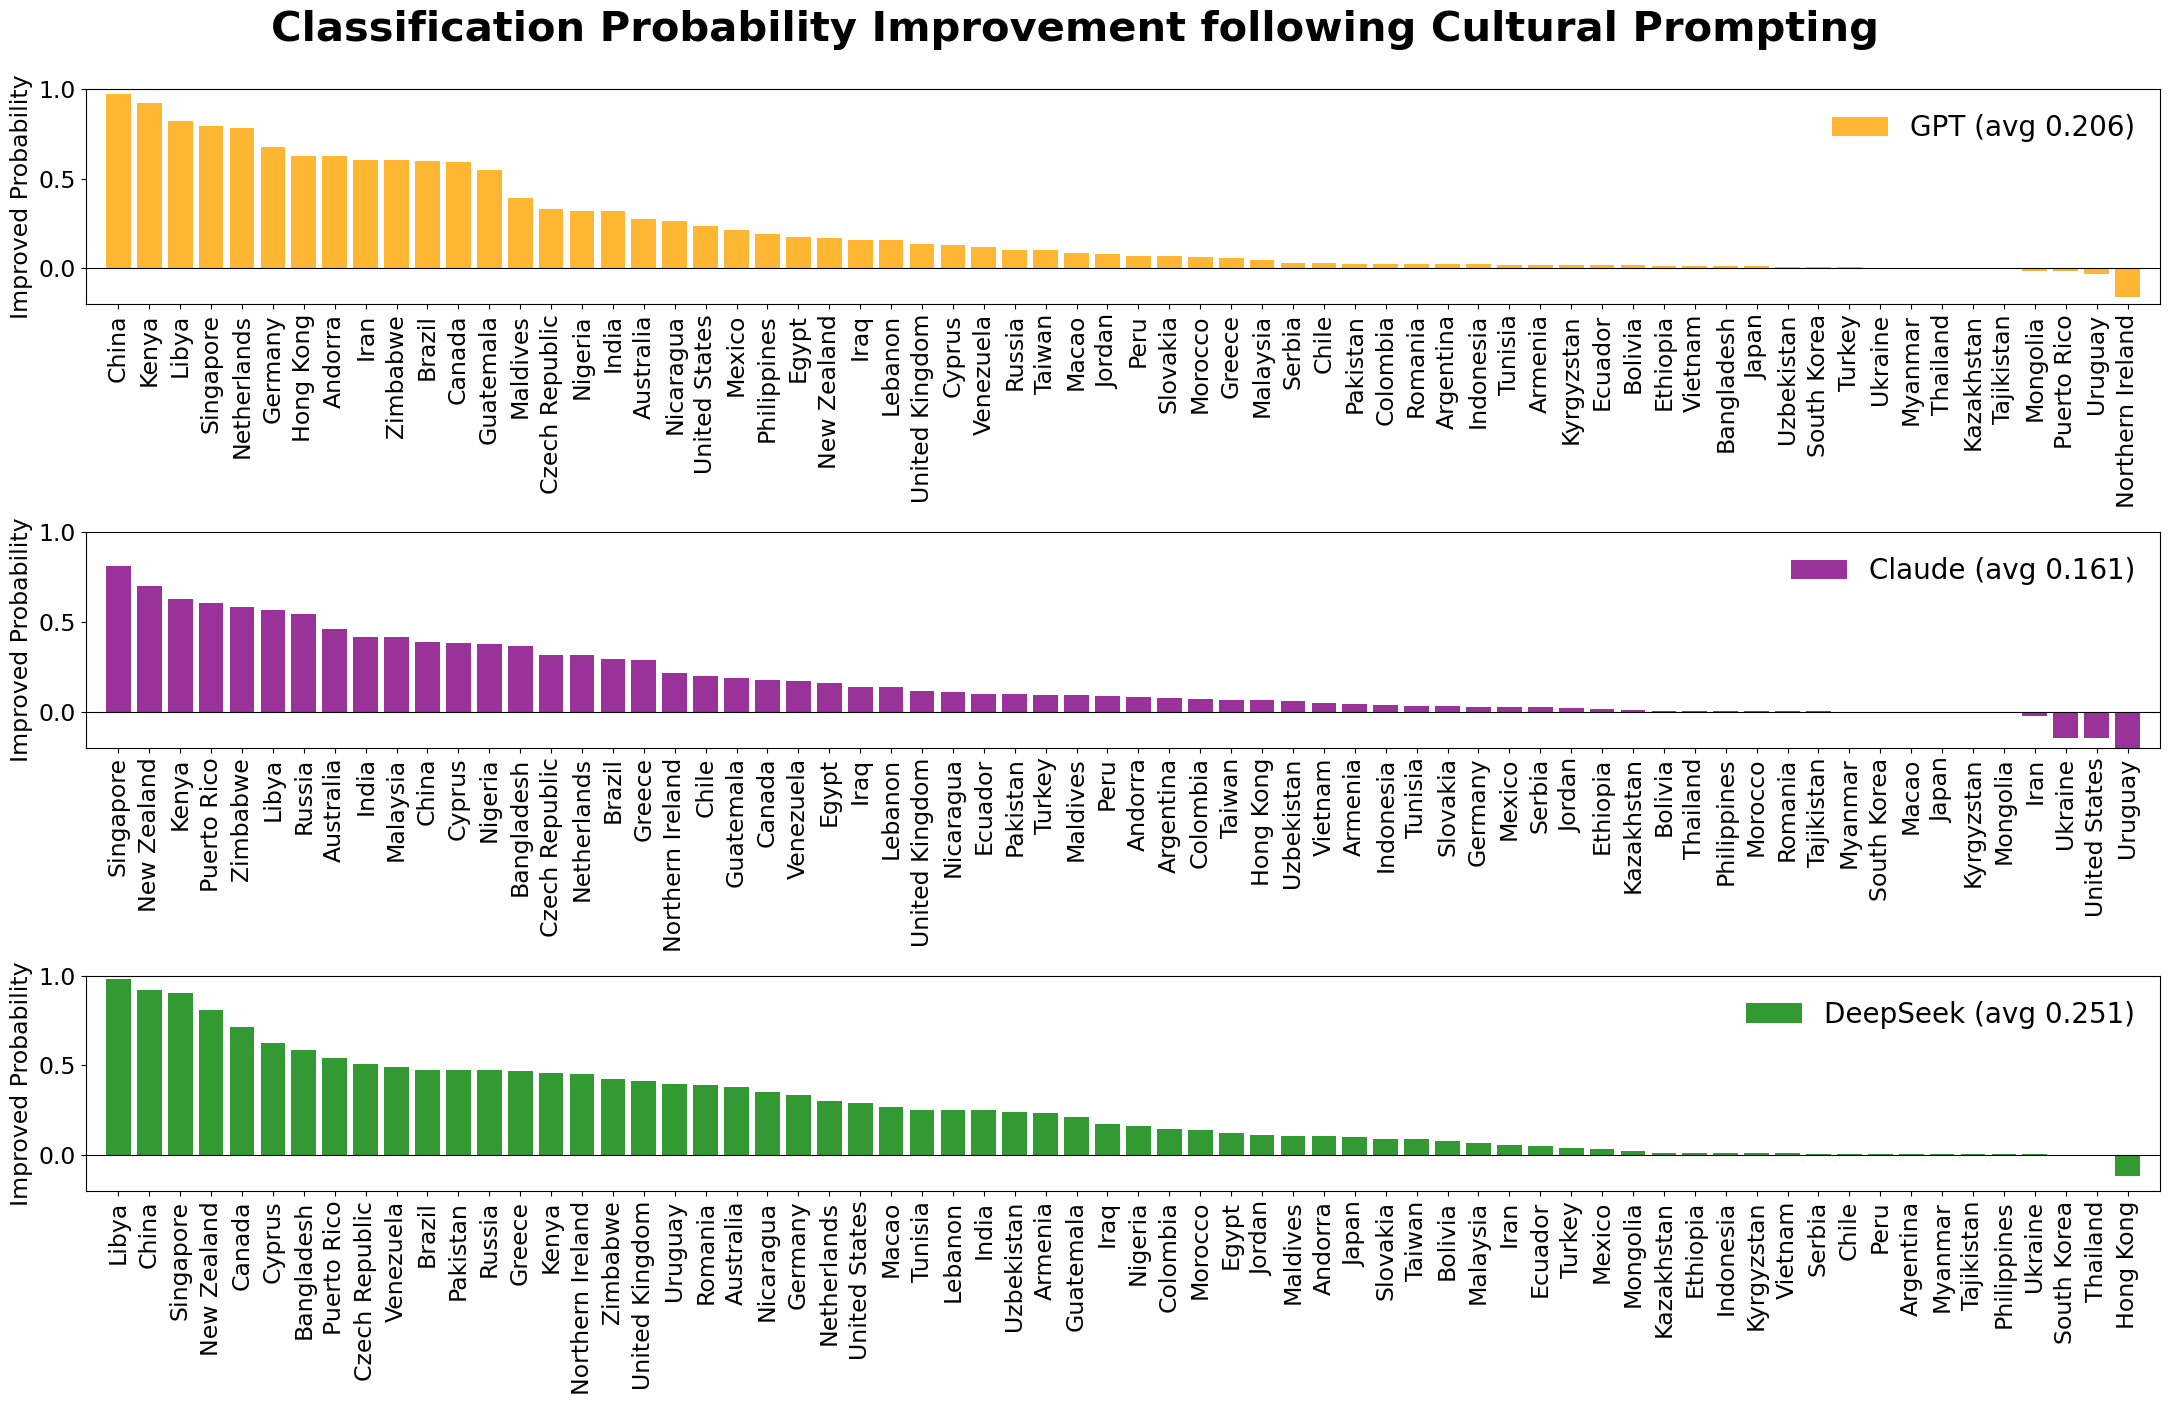

In [12]:
visualize_prob_improve()

### Quality check: best/worst/default represented countries

Which are the **best** represented countries

In [22]:
# var_prob = 'gpt_ctry_prob'
var_prob = 'claude_ctry_prob'
# var_prob = 'deepseek_ctry_prob'

In [23]:
df_clf.sort_values(var_prob, ascending=False).head(10)[[var_prob, "samples", "f1"]]

,claude_ctry_prob,samples,f1
Country,,,
Germany,0.954,1528,0.936
New Zealand,0.920,1057,0.896
Australia,0.897,1813,0.875
United Kingdom,0.891,2609,0.879
Canada,0.864,4018,0.900
Northern Ireland,0.838,447,0.856
Singapore,0.834,2012,0.918
Russia,0.653,1810,0.892
Kenya,0.629,1266,0.915


Which are the **worst** represented countries

In [24]:
df_clf.sort_values(var_prob, ascending=True).head(10)[[var_prob, "samples", "f1"]]

,claude_ctry_prob,samples,f1
Country,,,
Japan,0.002,1353,0.981
Myanmar,0.002,1200,0.960
Philippines,0.004,1200,0.941
Tajikistan,0.004,1200,0.925
Thailand,0.006,1500,0.891
Bolivia,0.007,2067,0.894
Mongolia,0.007,1638,0.899
Kyrgyzstan,0.008,1200,0.886
South Korea,0.008,1245,0.914


Which country the model **default** representation is similar to?
- Apply each country classifier to predict the probability of model default representation

In [25]:
# df_clf.sort_values('gpt_default_prob', ascending=False).head(10)[[var_prob, "samples", "f1"]]
df_clf.sort_values('claude_default_prob', ascending=False).head(10)[['claude_default_prob',var_prob, "samples", "f1"]]
# df_clf.sort_values('deepseek_default_prob', ascending=False).head(10)[[var_prob, "samples", "f1"]]

,claude_default_prob,claude_ctry_prob,samples,f1
Country,,,,
Germany,0.928,0.954,1528,0.936
Uruguay,0.813,0.422,1000,0.881
United Kingdom,0.776,0.891,2609,0.879
Canada,0.686,0.864,4018,0.900
Northern Ireland,0.624,0.838,447,0.856
United States,0.578,0.430,2596,0.894
Australia,0.437,0.897,1813,0.875
Ukraine,0.288,0.144,1289,0.866
Greece,0.286,0.575,1200,0.944


### Classifier Performancs VS Heterogeneity 
**Negative** correlation:
- Heterogeneous countries have less obvious patterns and thus low classification performance
- Country heterogeneity measured by average item variance for each country

In [15]:
df_std_byitem = df_wvs.groupby(level='Country')[items].std()
df_clf['ctry_std'] = df_std_byitem.mean(axis=1)

In [ ]:
def visulize_ctry_heterogeneity_sup(x_col='ctry_std', y_col='f1'):
    """
    Heterogeneity VS Classifier performance / LLM accuracy
    x_col: column for x-axis
    y_col: single column for y-axis
    """
    from scipy import stats
    from matplotlib.lines import Line2D

    x = df_clf[x_col]
    y = df_clf[y_col]
    r, p = stats.pearsonr(x, y)
    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    label = f'r = {r:.3f}\n{p_str}'

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(x, y, s=30, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.plot(x_line, y_line, color='red', linewidth=1.5, linestyle='--', alpha=0.8)

    for ctry, row in df_clf.iterrows():
        ax.annotate(ctry, (row[x_col], row[y_col]), fontsize=8,
                    xytext=(3, 3), textcoords='offset points', color='#444444')

    legend_handle = Line2D([], [], color='none', label=label)
    ax.legend(handles=[legend_handle], fontsize=12, frameon=False)

    ax.set_xlabel("Country Heterogeneity", fontsize=12)
    ax.set_ylabel("Country Classifier F1 Score", fontsize=12)
    ax.set_title(f'Country Classifier Performance VS. Country Heterogeneity', fontsize=12, fontweight="bold", pad=10)
    ax.tick_params(axis='both', labelsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    # plt.savefig(f'./supfig/sup1_heterogeneity.pdf', dpi=300, bbox_inches='tight')
    plt.show()

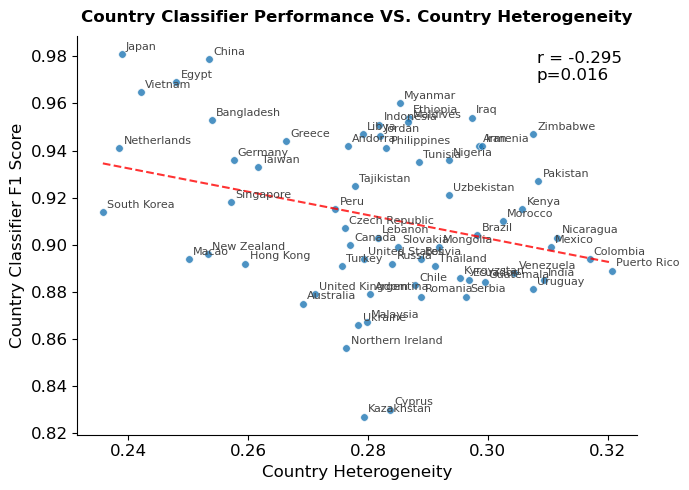

In [17]:
visulize_ctry_heterogeneity_sup()

In [ ]:
def visulize_ctry_heterogeneity(x_col, y_col):
    """
    Heterogeneity VS Classifier performance / LLM accuracy
    x_col: column for x-axis
    y_col: list of columns, one subplot each
    """
    from scipy import stats
    from matplotlib.lines import Line2D

    n = len(y_col)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, y_col):
        x = df_clf[x_col]
        y = df_clf[col]
        r, p = stats.pearsonr(x, y)
        p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
        label = f'r = {r:.3f}, {p_str}'

        slope, intercept, *_ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept

        ax.scatter(x, y, s=30, alpha=0.8, edgecolors='white', linewidths=0.5)
        ax.plot(x_line, y_line, color='steelblue', linewidth=1.5, linestyle='--', alpha=0.8)

        for ctry, row in df_clf.iterrows():
            ax.annotate(ctry, (row[x_col], row[col]), fontsize=5.5,
                        xytext=(3, 3), textcoords='offset points', color='#444444')

        legend_handle = Line2D([], [], color='none', label=label)
        ax.legend(handles=[legend_handle], fontsize=10, frameon=True)

        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel(col, fontsize=11)
        # ax.set_title(f'Country Classifier Performance VS. Country Heterogeneity', fontsize=12, fontweight="bold", pad=10)
            
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

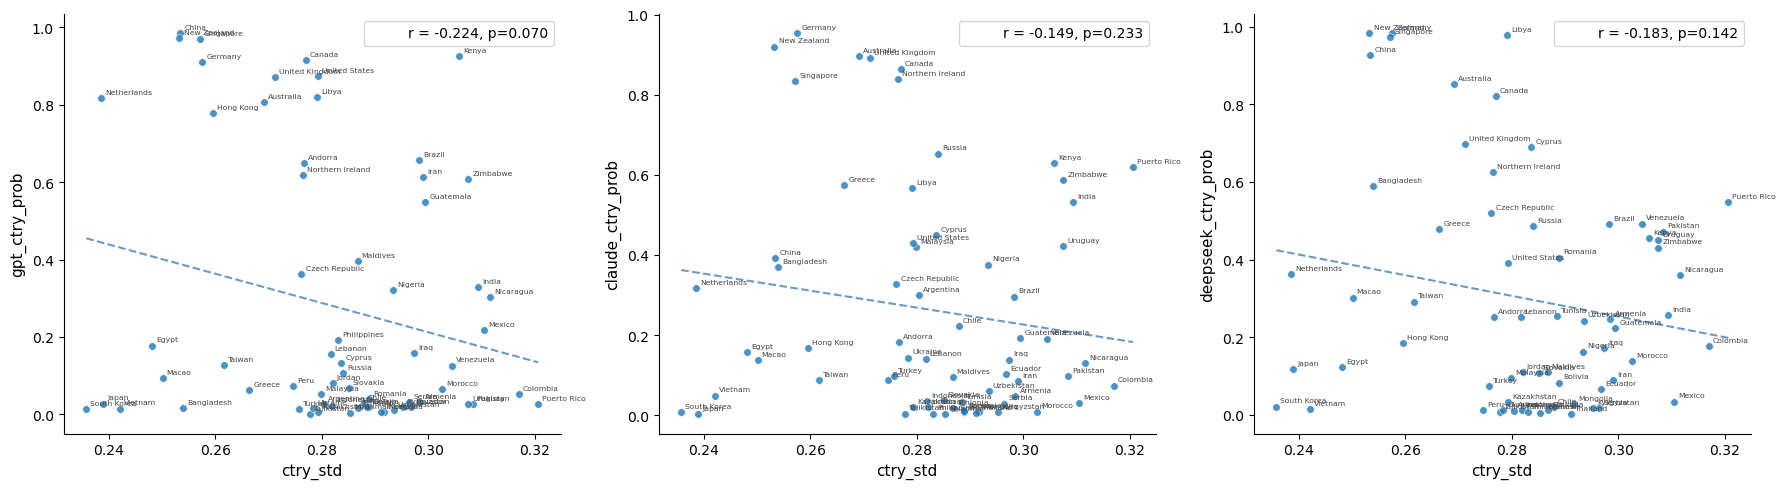

In [ ]:
# no significant correlation between country heterogeneity and llm representation accuracy
visulize_ctry_heterogeneity(x_col = 'ctry_std', y_col = ['gpt_ctry_prob', 'claude_ctry_prob', 'deepseek_ctry_prob'])

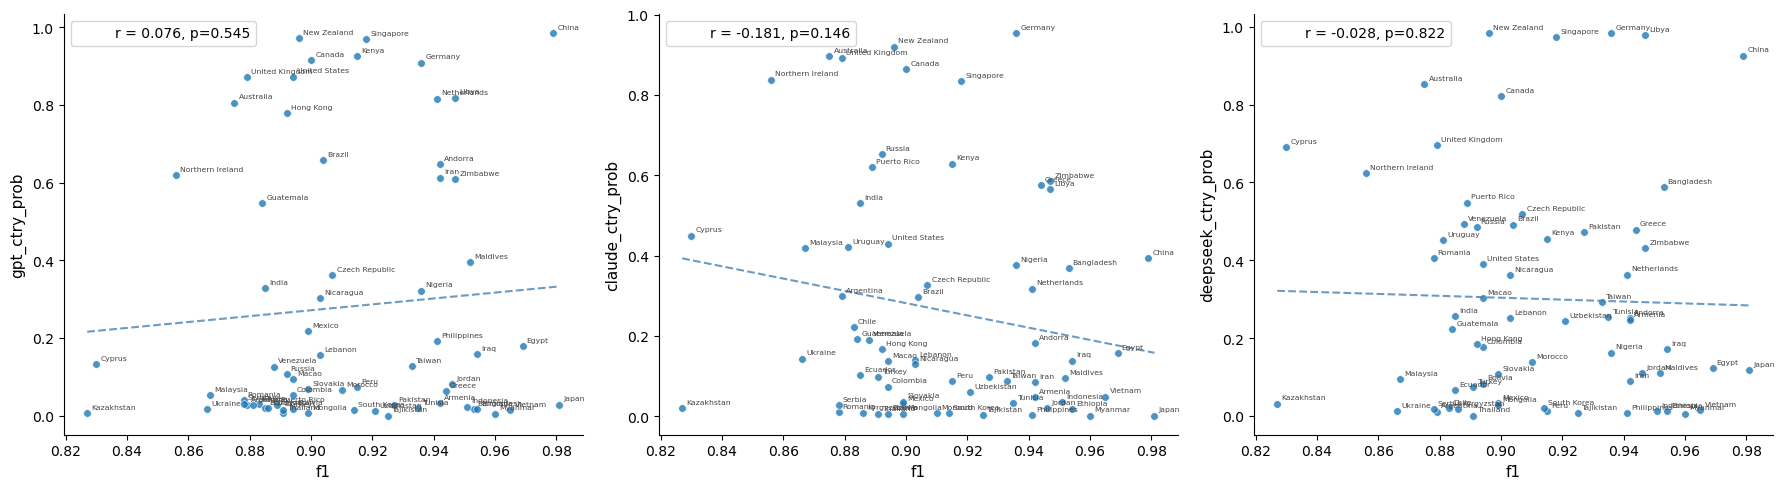

In [45]:
# no significant correlation between country classifier performance and llm representation probability
visulize_ctry_heterogeneity(x_col = 'f1', y_col = ['gpt_ctry_prob', 'claude_ctry_prob', 'deepseek_ctry_prob'])

-------------------------------------the end-------------------------------------

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~the end~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~